#Trabajo Final de Herramientas Basicas

##Búsqueda y selección del dataset


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [2]:
data= pd.read_csv('/content/drive/MyDrive/S&P 500 Stock Prices 2014-2017.csv')

- Fuente: https://mavenanalytics.io/data-playground/s-p-500-stock-prices
- Objetivo: Analisis del valor de las acciones de S&P 500 entre 2014 y 2017
- Preguntas Iniciales: ¿como evoluciona el valor general de las acciones a lo largo del tiempo?¿Cuales fueron las de mejor rendimiento en todo este tiempo y las de peor?¿Podemos observar correlación entre las mejores acciones?

### Diccionario
- symbol: codigo de designación de la empresa
- open: valor de apertura en USD
- high: valor más alto del día en USD
- low: valor más bajo del día en USD
- close: valor de cierre en USD
- volume: cantidad de acciones negociadas

##Ingesta y limpieza

###Leer el data set en Python

In [3]:
data.head(10)

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391
5,ABT,2014-01-02,38.0900,38.4000,38.0000,38.2300,4967472
6,ACN,2014-01-02,81.5000,81.9200,81.0900,81.1300,2405384
7,ADBE,2014-01-02,59.0600,59.5300,58.9400,59.2900,2746370
8,ADI,2014-01-02,49.5200,49.7500,49.0400,49.2800,2799092
9,ADM,2014-01-02,43.2200,43.2900,42.7900,42.9900,2753765


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  object 
 1   date    497472 non-null  object 
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 26.6+ MB


In [5]:
data.tail()

,symbol,date,open,high,low,close,volume
497467,XYL,2017-12-29,68.53,68.80,67.92,68.20,1046677
497468,YUM,2017-12-29,82.64,82.71,81.59,81.61,1347613
497469,ZBH,2017-12-29,121.75,121.95,120.62,120.67,1023624
497470,ZION,2017-12-29,51.28,51.55,50.81,50.83,1261916
497471,ZTS,2017-12-29,72.55,72.76,72.04,72.04,1704122


In [6]:
data.columns

Index(['symbol', 'date', 'open', 'high', 'low', 'close', 'volume'], dtype='object')

###Auditar tipos, nulos, duplicados y outliers

In [7]:
data.duplicated().sum()

np.int64(0)

####Tras buscar duplicados determinamos que no hay ninguno y podemos continuar con el analisis

In [8]:
data.isnull().sum()

,0
symbol,0
date,0
open,11
high,8
low,8
close,0
volume,0


####Tras observar que contamos con valores nulos determinamos, basados en el bajo porcentaje que representan estos en el total de datos, eliminar las filas nulas

In [9]:
data.dropna(inplace=True)

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
data.isnull().sum()

,0
symbol,0
date,0
open,0
high,0
low,0
close,0
volume,0


###Estandarizar fechas, categorías y unidades

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 497461 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497461 non-null  object 
 1   date    497461 non-null  object 
 2   open    497461 non-null  float64
 3   high    497461 non-null  float64
 4   low     497461 non-null  float64
 5   close   497461 non-null  float64
 6   volume  497461 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 30.4+ MB


####Tras ver los tipos de dato que contiene el dataset vemos que la columna date esta en un tipo erroneo de clasificación por esto lo modificamos

In [13]:
data['date']=pd.to_datetime(data['date'])
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 497461 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   symbol  497461 non-null  object        
 1   date    497461 non-null  datetime64[ns]
 2   open    497461 non-null  float64       
 3   high    497461 non-null  float64       
 4   low     497461 non-null  float64       
 5   close   497461 non-null  float64       
 6   volume  497461 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 30.4+ MB


##Exploración y visualización

###¿como evoluciona el valor general de las acciones a lo largo del tiempo?

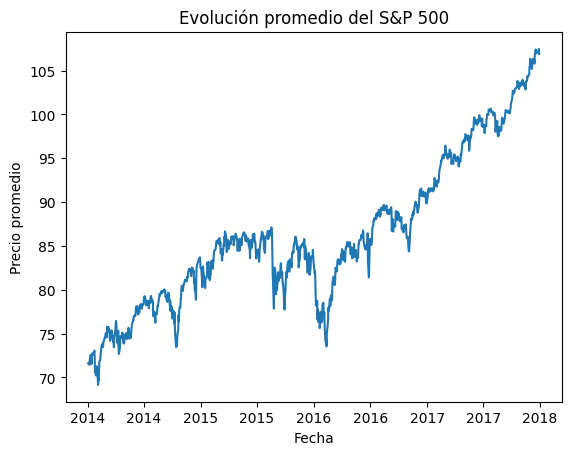

In [14]:
data = data.sort_values(['symbol', 'date'])
promedio = data.groupby('date')['close'].mean()

plt.figure()
plt.plot(promedio.index, promedio.values)

plt.title('Evolución promedio del S&P 500')
plt.xlabel('Fecha')
plt.ylabel('Precio promedio')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.show()

###Con este grafico podemos observar claramente como la tendencia de las acciones en promedio tiene una tendencia creciente a lo largo de los años

###¿Cuales fueron las de mejor rendimiento en todo este tiempo?

In [15]:
data = data.sort_values(['symbol', 'date'])
rendimiento = data.groupby('symbol')['close'].agg(['first', 'last'])
rendimiento['return'] = ((rendimiento['last'] - rendimiento['first']) / rendimiento['first']) * 100
rendimiento = rendimiento.sort_values('return', ascending=False)
top = rendimiento.head(10)
bottom = rendimiento.tail(10)

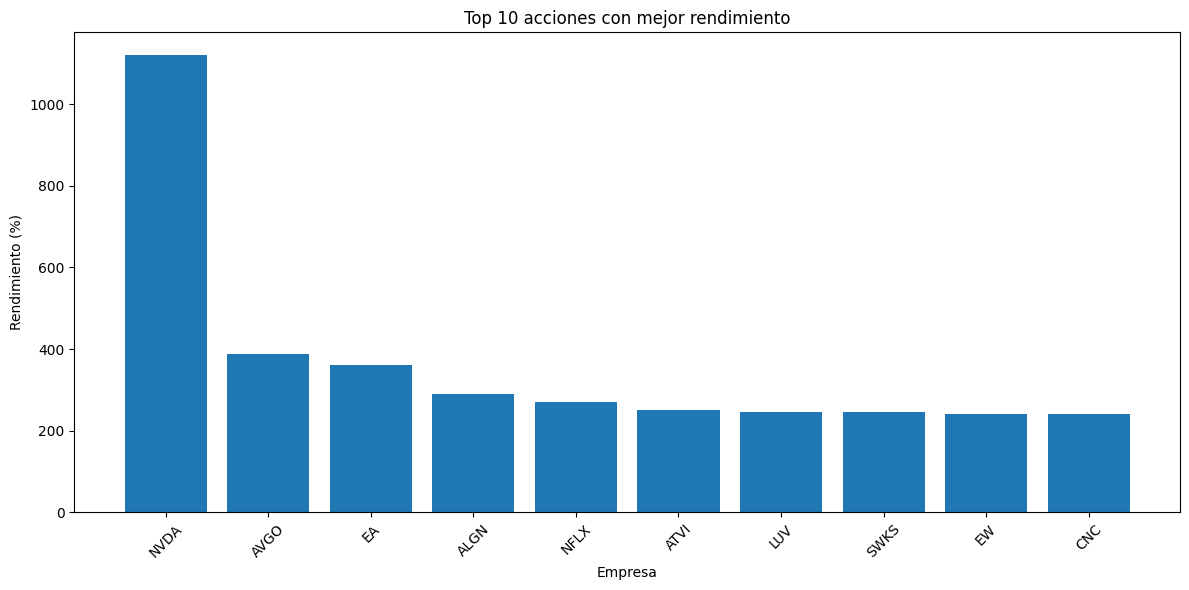

In [16]:

plt.figure(figsize=(12,6))
plt.bar(top.index, top['return'])
plt.title('Top 10 acciones con mejor rendimiento')
plt.xlabel('Empresa')
plt.ylabel('Rendimiento (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###Gracias a esto puedo determinar que las acciones de mayor rendimiento fueron las de NVDA

###¿Y cuales fueron las  de peor?

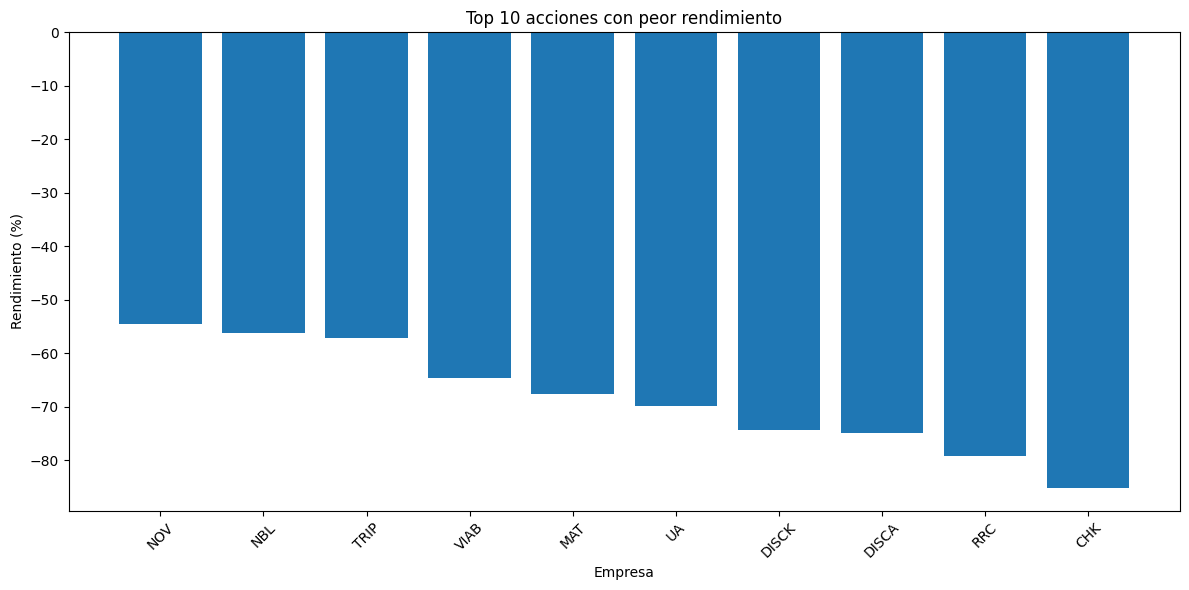

In [17]:
plt.figure(figsize=(12,6))

plt.bar(bottom.index, bottom['return'])

plt.title('Top 10 acciones con peor rendimiento')
plt.xlabel('Empresa')
plt.ylabel('Rendimiento (%)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###Gracias a esto puedo determinar que las acciones de peor rendimiento fueron las de CHK

###¿Podemos observar correlación entre las mejores acciones?

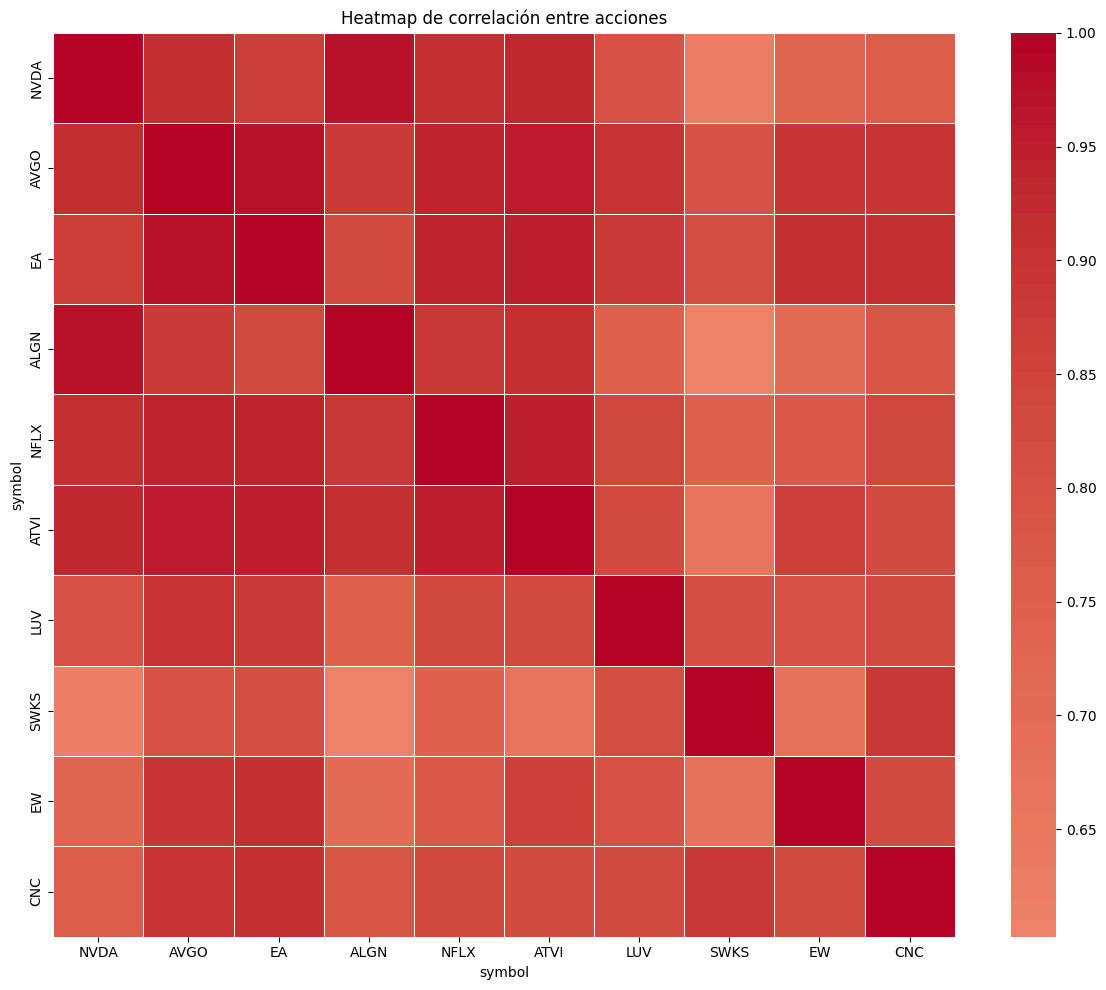

In [18]:
top10 = rendimiento.sort_values('return', ascending=False).head(10).index
top10 = rendimiento.head(10).index.tolist()
filtered = data[data['symbol'].isin(top10)]
pivot = filtered.pivot(index='date', columns='symbol', values='close')
pivot = pivot[top10]
correlation = pivot.corr()
plt.figure(figsize=(12,10))

sns.heatmap(correlation,
            cmap='coolwarm',
            center=0,
            linewidths=0.5)

plt.title('Heatmap de correlación entre acciones')
plt.tight_layout()

plt.show()

###Como podemos observar en el heatmap hay una gran correlación entre las primeras 6 acciones